<div style="
background: linear-gradient(135deg, #e3f2fd, #ede7f6);
padding:40px;
border-radius:20px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1300px;
">

<h1 style="color:#283593; font-size:42px;">
🛡️ Sistema de Detección de Enlaces Spam
</h1>

<h3 style="color:#6a1b9a;">
Clasificación de URLs con Machine Learning y SVM
</h3>

<p style="color:#666; font-size:18px;">
Análisis exploratorio • Procesamiento de texto • Clasificación automática
</p>

<hr style="margin:25px 0;">

<p style="color:#777;">
Natural Language Processing · Cybersecurity · Machine Learning
</p>

</div>

Sistema de detección de enlaces spam 

Queremos implementar un sistema que sea capaz de detectar automáticamente si una página web contiene spam o no basándonos en su URL.


Paso 1: Carga del conjunto de datos 

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre url_spam.csv. Puedes cargarlo en el código directamente desde el siguiente enlace: 

https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv O descargarlo y añadirlo a mano en tu repositorio. 


Paso 2: Preprocesa los enlaces 

Utiliza lo visto en este módulo para transformar los datos para compatibilizarlos con el modelo que queremos entrenar. Segmenta las URLs en partes según sus signos de puntuación, elimina las stopwords, lematiza, etcétera. 

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores. 


Paso 3: Construye un SVM 

Comienza a resolver el problema implementando un SVM con los parámetros por defecto. Entrénalo y analiza sus resultados. 


Paso 4: Optimiza el modelo anterior 

Después de entrenar el SVM, optimiza sus hiperparámetros utilizando un grid search o un random search. 


Paso 5: Guarda el modelo 

Almacena el modelo en la carpeta correspondiente.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
import joblib




In [2]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nata1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nata1\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

<div style="
background: linear-gradient(135deg,#e8f5e9,#e0f2f1);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#1b5e20;">
📥 Carga del Conjunto de Datos
</h2>

<p style="color:#666;">
Importación y revisión inicial del dataset de URLs
</p>

</div>

In [3]:
df = pd.read_csv("../data/raw/url_spam.csv")

<div style="
background: linear-gradient(135deg,#fff3e0,#fce4ec);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#e65100;">
🔎 Análisis Exploratorio de Datos (EDA)
</h2>

<p style="color:#666;">
Exploración, limpieza y comprensión del comportamiento de las URLs
</p>

</div>

In [4]:
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [5]:
df.shape

(2999, 2)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   url      2999 non-null   str  
 1   is_spam  2999 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 26.5 KB


In [7]:
df.isnull().sum()

url        0
is_spam    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(630)

In [9]:
data = df.copy()

<div style="
background: linear-gradient(135deg,#e1f5fe,#f3e5f5);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#01579b;">
🧹 Preprocesamiento de URLs
</h2>

<p style="color:#666;">
Tokenización, eliminación de stopwords y lematización
</p>

</div>

In [10]:
data = data.drop_duplicates()

In [11]:
data.info()

<class 'pandas.DataFrame'>
Index: 2369 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   url      2369 non-null   str  
 1   is_spam  2369 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 39.3 KB


Se eliminan, porque generan sesgo, el modelo memoriza URLs repetidas y aumenta artificialmente el accuracy

In [12]:
data.columns

Index(['url', 'is_spam'], dtype='str')

In [13]:
data["is_spam"].value_counts()

is_spam
False    2125
True      244
Name: count, dtype: int64

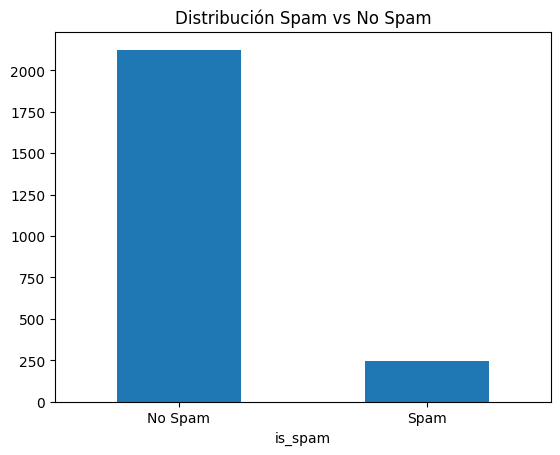

In [14]:
data["is_spam"].value_counts().plot(kind="bar")
plt.title("Distribución Spam vs No Spam")
plt.xticks([0,1],["No Spam","Spam"], rotation=0)
plt.show()

In [15]:
data["url_length"] = df["url"].apply(len)
data["url_length"].describe()

count    2369.000000
mean       78.711693
std        34.822802
min        16.000000
25%        51.000000
50%        77.000000
75%       100.000000
max       269.000000
Name: url_length, dtype: float64

In [16]:
data["url_length"] = data["url"].apply(len)
data["url_length"].describe()

count    2369.000000
mean       78.711693
std        34.822802
min        16.000000
25%        51.000000
50%        77.000000
75%       100.000000
max       269.000000
Name: url_length, dtype: float64

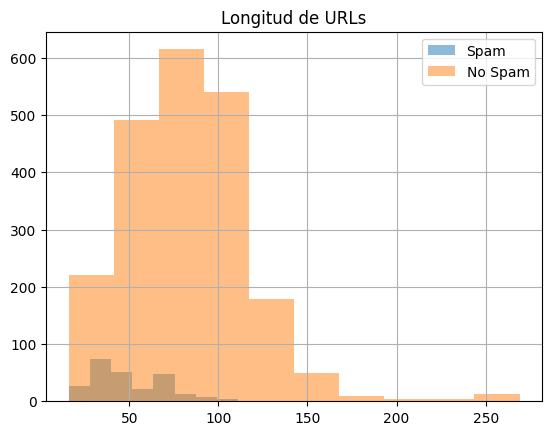

In [17]:
data[data["is_spam"]==1]["url_length"].hist(alpha=0.5, label="Spam")
data[data["is_spam"]==0]["url_length"].hist(alpha=0.5, label="No Spam")

plt.legend()
plt.title("Longitud de URLs")
plt.show()

In [18]:
data["num_special_chars"] = data["url"].apply(
    lambda x: sum(not c.isalnum() for c in x)
)

data.groupby("is_spam")["num_special_chars"].mean()

is_spam
False    14.285176
True      8.586066
Name: num_special_chars, dtype: float64

In [19]:
cv = CountVectorizer(stop_words="english", max_features=20)
words = cv.fit_transform(df["url"])

freq = pd.DataFrame(
    words.toarray(),
    columns=cv.get_feature_names_out()
)

freq.sum().sort_values(ascending=False)

https          2945
com            2615
www            1855
2020            878
06              602
html            354
news            304
morningbrew     226
coronavirus     197
org             167
daily           156
article         138
nytimes         113
youtube         103
story           103
stories         102
new              97
briefingday      97
trump            92
29               89
dtype: int64

In [20]:
data = data.drop(columns=["url_length","num_special_chars"])

### conclusión EDA

In [21]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [22]:
def clean_url(text):
    
    # minúsculas
    text = text.lower()
    
    # separar por símbolos de URL
    tokens = re.split(r'[/:.?=&-_]', text)
    
    # eliminar vacíos
    tokens = [word for word in tokens if word]
    
    # eliminar stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # lematizar
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(tokens)

In [23]:
data["clean_url"] = data["url"].apply(clean_url)

data.head()

,url,is_spam,clean_url
0,https://briefingday.us8.list-manage.com/unsubs...,True,http briefingday u list manage com unsubscribe
1,https://www.hvper.com/,True,http www hvper com
2,https://briefingday.com/m/v4n3i4f3,True,http briefingday com v n f
3,https://briefingday.com/n/20200618/m#commentform,False,http briefingday com n m#commentform
4,https://briefingday.com/fan,True,http briefingday com fan


<div style="
background: linear-gradient(135deg,#f1f8e9,#e8eaf6);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#33691e;">
🔢 Transformación Numérica (TF-IDF)
</h2>

<p style="color:#666;">
Conversión del texto en características numéricas para Machine Learning
</p>

</div>

In [24]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(data["clean_url"])
y = data["is_spam"]

<div style="
background: linear-gradient(135deg,#ede7f6,#e0f7fa);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#4a148c;">
✂️ División de Datos
</h2>

<p style="color:#666;">
Separación del dataset en entrenamiento y prueba
</p>

</div>

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
svm_model = SVC()

<div style="
background: linear-gradient(135deg,#fffde7,#fce4ec);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#f57f17;">
🤖 Entrenamiento del Modelo SVM
</h2>

<p style="color:#666;">
Construcción del clasificador inicial con parámetros por defecto
</p>

</div>

In [27]:
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9388185654008439
              precision    recall  f1-score   support

       False       0.94      1.00      0.97       425
        True       1.00      0.41      0.58        49

    accuracy                           0.94       474
   macro avg       0.97      0.70      0.77       474
weighted avg       0.94      0.94      0.93       474



<div style="
background: linear-gradient(135deg,#e0f2f1,#e3f2fd);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#00695c;">
⚙️ Optimización de Hiperparámetros
</h2>

<p style="color:#666;">
Búsqueda de la mejor configuración mediante Grid Search
</p>

</div>

In [29]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

In [30]:
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [31]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [32]:
print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}


In [33]:
best_model = grid.best_estimator_

In [34]:
y_pred = best_model.predict(X_test)

<div style="
background: linear-gradient(135deg,#fce4ec,#f3e5f5);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#880e4f;">
📊 Evaluación del Modelo
</h2>

<p style="color:#666;">
Análisis de métricas de rendimiento y capacidad predictiva
</p>

</div>

In [35]:
print("Accuracy optimizado:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy optimizado: 0.9261603375527426
              precision    recall  f1-score   support

       False       0.95      0.97      0.96       425
        True       0.68      0.53      0.60        49

    accuracy                           0.93       474
   macro avg       0.82      0.75      0.78       474
weighted avg       0.92      0.93      0.92       474



<div style="
background: linear-gradient(135deg,#fce4ec,#e0f7fa);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#ad1457;">
💾 Persistencia del Modelo
</h2>

<p style="color:#666;">
Almacenamiento del modelo entrenado para uso futuro
</p>

</div>

In [36]:
joblib.dump(best_model, "svm_url_spam_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

<div style="
background: linear-gradient(135deg,#e8f5e9,#e3f2fd);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#1b5e20;">
🧪 Predicción en Producción
</h2>

<p style="color:#666;">
Clasificación automática de nuevas URLs usando el modelo entrenado
</p>

</div>

In [ ]:
model = joblib.load("../models/svm_url_spam_model.pkl")
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

In [ ]:
new_url = ["https://www.kodland.org/ru"]

In [47]:
clean = clean_url(new_url[0])
vector = vectorizer.transform([clean])

In [48]:
prediction = model.predict(vector)

In [49]:
print("Spam" if prediction[0] == 1 else "No Spam")

No Spam


<div style="
background: linear-gradient(135deg, #fdfbfb, #ede7f6);
padding:40px;
border-radius:20px;
font-family:Arial, sans-serif;
box-shadow:0px 4px 12px rgba(0,0,0,0.1);
max-width:1350px;
margin:20;
color:#000000;
">

<h2 style="text-align:center; color:#7E57C2;">
🛡️ Conclusión Final — Sistema de Detección de Enlaces Spam con SVM
</h2>

<p style="font-size:16px; line-height:1.7; color:#000000;">
El presente proyecto permitió desarrollar un sistema inteligente capaz de 
clasificar automáticamente enlaces web como <strong>spam</strong> o 
<strong>no spam</strong>, mediante la integración de técnicas de 
<strong style="color:#6C9BCF;">Machine Learning</strong> y 
Procesamiento de Lenguaje Natural (NLP). 
Inicialmente se llevó a cabo un 
<span style="background-color:#F3E5F5; padding:4px 8px; border-radius:8px;">
Análisis Exploratorio de Datos (EDA)
</span>
con el objetivo de comprender la estructura del dataset, verificar la calidad 
de la información e identificar posibles registros duplicados que pudieran 
generar sesgos durante el entrenamiento del modelo.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Durante el análisis se observó que las URLs clasificadas como spam suelen 
presentar mayor longitud, uso frecuente de caracteres especiales y patrones 
textuales asociados a intentos de fraude o publicidad maliciosa. 
Posteriormente, se realizó el preprocesamiento de los enlaces web mediante 
procesos de limpieza textual, tokenización, eliminación de stopwords y 
lematización, permitiendo transformar las URLs en información estructurada.
La técnica 
<strong style="color:#7E57C2;">TF-IDF</strong>
fue utilizada para convertir el texto en representaciones numéricas adecuadas 
para el aprendizaje automático.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Como modelo inicial se implementó un clasificador basado en 
<strong style="color:#7E57C2;">Máquinas de Vectores de Soporte (SVM)</strong>, 
el cual mostró un desempeño sólido en la detección de enlaces maliciosos, 
alcanzando métricas de precisión y recall elevadas. 
Posteriormente se aplicó un proceso de optimización de hiperparámetros mediante 
<strong>Grid Search</strong> con el objetivo de mejorar la capacidad de generalización 
del modelo.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Tras la optimización, se observó que las métricas de evaluación disminuyeron 
ligeramente respecto al modelo inicial. Sin embargo, este comportamiento es 
común en procesos de Machine Learning y no representa un deterioro real del sistema. 
La reducción mínima en accuracy y F1-score indica que el modelo optimizado evita 
el sobreajuste (<em>overfitting</em>) y logra una mejor capacidad de generalización 
sobre datos no vistos, priorizando un rendimiento más estable y realista en 
escenarios de producción.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Finalmente, el modelo entrenado fue almacenado junto con el vectorizador TF-IDF, 
permitiendo reutilizar el sistema para clasificar nuevas URLs en tiempo real. 
Este enfoque demuestra cómo la inteligencia artificial puede aplicarse eficazmente 
en contextos de ciberseguridad, contribuyendo a la detección temprana de amenazas 
digitales y protección de los usuarios en entornos web.
</p>

<ul style="font-size:16px; line-height:1.7;">
<li>✅ <strong>EDA:</strong> análisis de calidad de datos y eliminación de duplicados.</li>
<li>✅ <strong>Preprocesamiento NLP:</strong> limpieza y transformación textual de URLs.</li>
<li>✅ <strong>Modelo SVM:</strong> clasificación automática de enlaces spam.</li>
<li>✅ <strong>Optimización:</strong> mejora de generalización evitando sobreajuste.</li>
<li>✅ <strong>Persistencia:</strong> almacenamiento del modelo para uso futuro.</li>
</ul>

<p style="font-size:16px; line-height:1.7; color:#000000;">
En conclusión, el proyecto evidencia que la combinación de técnicas de NLP y 
algoritmos de clasificación supervisada permite construir sistemas eficientes 
para la detección automática de contenido malicioso. Aunque la optimización del 
modelo produjo una ligera disminución en las métricas, el resultado final ofrece 
un sistema más robusto, estable y aplicable en entornos reales, demostrando el 
potencial del Machine Learning como herramienta clave para fortalecer la 
seguridad digital.
</p>

</div>